# 05 - Historical exposure screening and official ICNF comparison

Inspect the validated historical/descriptive output: **1 km mainland grid cells with fire recurrence measured in a 2 km context**. The evidence window is 2016–2025. This notebook reads the completed GeoPackage and comparison tables; it creates no prediction, probability, purchase decision, or recommendation category.

In [1]:
from pathlib import Path
import json
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print('Repository root resolved; notebook paths are reported relative to it.')

Repository root resolved; notebook paths are reported relative to it.


## Optional controlled screening validation

The default cells inspect the published GeoPackage. Enable this switch to recompute the bounded historical-screening attributes in memory and compare them with the existing output. It does not train a model or publish a replacement layer.

In [2]:
VALIDATE_HISTORICAL_SCREENING = False
if VALIDATE_HISTORICAL_SCREENING:
    from src.historical_exposure_screening import run_historical_exposure_screening
    screening_validation = run_historical_exposure_screening(validate_existing=True)
    print('Historical screening rerun matched the existing output:', screening_validation['deterministic_rerun']['analytical_values_exact'])
else:
    print('Using the validated published screening layer. Set VALIDATE_HISTORICAL_SCREENING=True for the bounded rerun check.')

Using the validated published screening layer. Set VALIDATE_HISTORICAL_SCREENING=True for the bounded rerun check.


In [3]:
import pandas as pd
import pyogrio
from src.historical_exposure_screening import METRICS_PATH, OUTPUT_LAYER, OUTPUT_PATH

metrics = json.loads(METRICS_PATH.read_text(encoding='utf-8'))
layer_info = pyogrio.read_info(OUTPUT_PATH, layer=OUTPUT_LAYER)
attributes = pyogrio.read_dataframe(
    OUTPUT_PATH,
    layer=OUTPUT_LAYER,
    read_geometry=False,
    columns=[
        'cell_id', 'history_start_year', 'history_end_year',
        'fire_years_history_10y_2km', 'historical_exposure_band',
        'official_icnf_hazard_class',
    ],
)

assert metrics['no_predictive_claim']
assert layer_info['features'] == len(attributes) == 89_112
assert layer_info['crs'] == 'EPSG:3763'
assert attributes['cell_id'].is_unique
assert set(attributes['history_start_year']) == {2016}
assert set(attributes['history_end_year']) == {2025}

print({
    'path': OUTPUT_PATH.relative_to(PROJECT_ROOT).as_posix(),
    'layer': OUTPUT_LAYER,
    'crs': layer_info['crs'],
    'features': layer_info['features'],
    'history_window': '2016-2025',
    'recurrence_context': '2 km outward context around each 1 km cell',
})

{'path': 'data/processed/spatial_outputs/historical_residential_wildfire_exposure_screening.gpkg', 'layer': 'historical_exposure_screening', 'crs': 'EPSG:3763', 'features': 89112, 'history_window': '2016-2025', 'recurrence_context': '2 km outward context around each 1 km cell'}


In [4]:
band_order = ['lower', 'moderate', 'higher']
hazard_order = ['null', 'very_low', 'low', 'medium', 'high', 'very_high', 'unmatched']

band_summary = (
    attributes.groupby('historical_exposure_band').size()
    .reindex(band_order, fill_value=0).rename('cell_count').to_frame()
)
band_summary['share_of_cells'] = band_summary['cell_count'] / len(attributes)
hazard_summary = (
    attributes.groupby('official_icnf_hazard_class').size()
    .reindex(hazard_order, fill_value=0).rename('cell_count').to_frame()
)
hazard_summary['share_of_cells'] = hazard_summary['cell_count'] / len(attributes)
cross_tab = pd.crosstab(
    attributes['historical_exposure_band'],
    attributes['official_icnf_hazard_class'],
).reindex(index=band_order, columns=hazard_order, fill_value=0)

expected_bands = pd.DataFrame(metrics['band_summary']).set_index('historical_exposure_band')
expected_hazards = pd.DataFrame(metrics['hazard_summary']).set_index('official_icnf_hazard_class')
pd.testing.assert_series_equal(band_summary['cell_count'], expected_bands['cell_count'], check_names=False)
pd.testing.assert_series_equal(hazard_summary['cell_count'], expected_hazards['cell_count'], check_names=False)
assert int(cross_tab.to_numpy().sum()) == 89_112

print(f"Validated empirical thresholds: lower 0-{metrics['thresholds']['lower_max']}, moderate 2-{metrics['thresholds']['moderate_max']}, higher 4-10 recorded fire years.")
display(band_summary.assign(share_of_cells=band_summary['share_of_cells'].map('{:.2%}'.format)))
display(hazard_summary.assign(share_of_cells=hazard_summary['share_of_cells'].map('{:.2%}'.format)))
display(cross_tab)

Validated empirical thresholds: lower 0-1, moderate 2-3, higher 4-10 recorded fire years.


,cell_count,share_of_cells
historical_exposure_band,,
lower,36645,41.12%
moderate,29919,33.57%
higher,22548,25.30%


,cell_count,share_of_cells
official_icnf_hazard_class,,
null,0,0.00%
very_low,27163,30.48%
low,17340,19.46%
medium,15303,17.17%
high,14735,16.54%
very_high,14112,15.84%
unmatched,459,0.52%


official_icnf_hazard_class,null,very_low,low,medium,high,very_high,unmatched
historical_exposure_band,,,,,,,
lower,0,14014,8611,5969,5268,2375,408
moderate,0,9344,5431,4961,5203,4943,37
higher,0,3805,3298,4373,4264,6794,14


## Visual review of the validated spatial evidence

These are the exported QGIS views of the same checked GeoPackage and summary tables above. They are descriptive historical exposure and official structural-hazard comparison views, not outputs from the machine-learning model.

reports/figures/historical_wildfire_exposure_screening_mainland_portugal.png


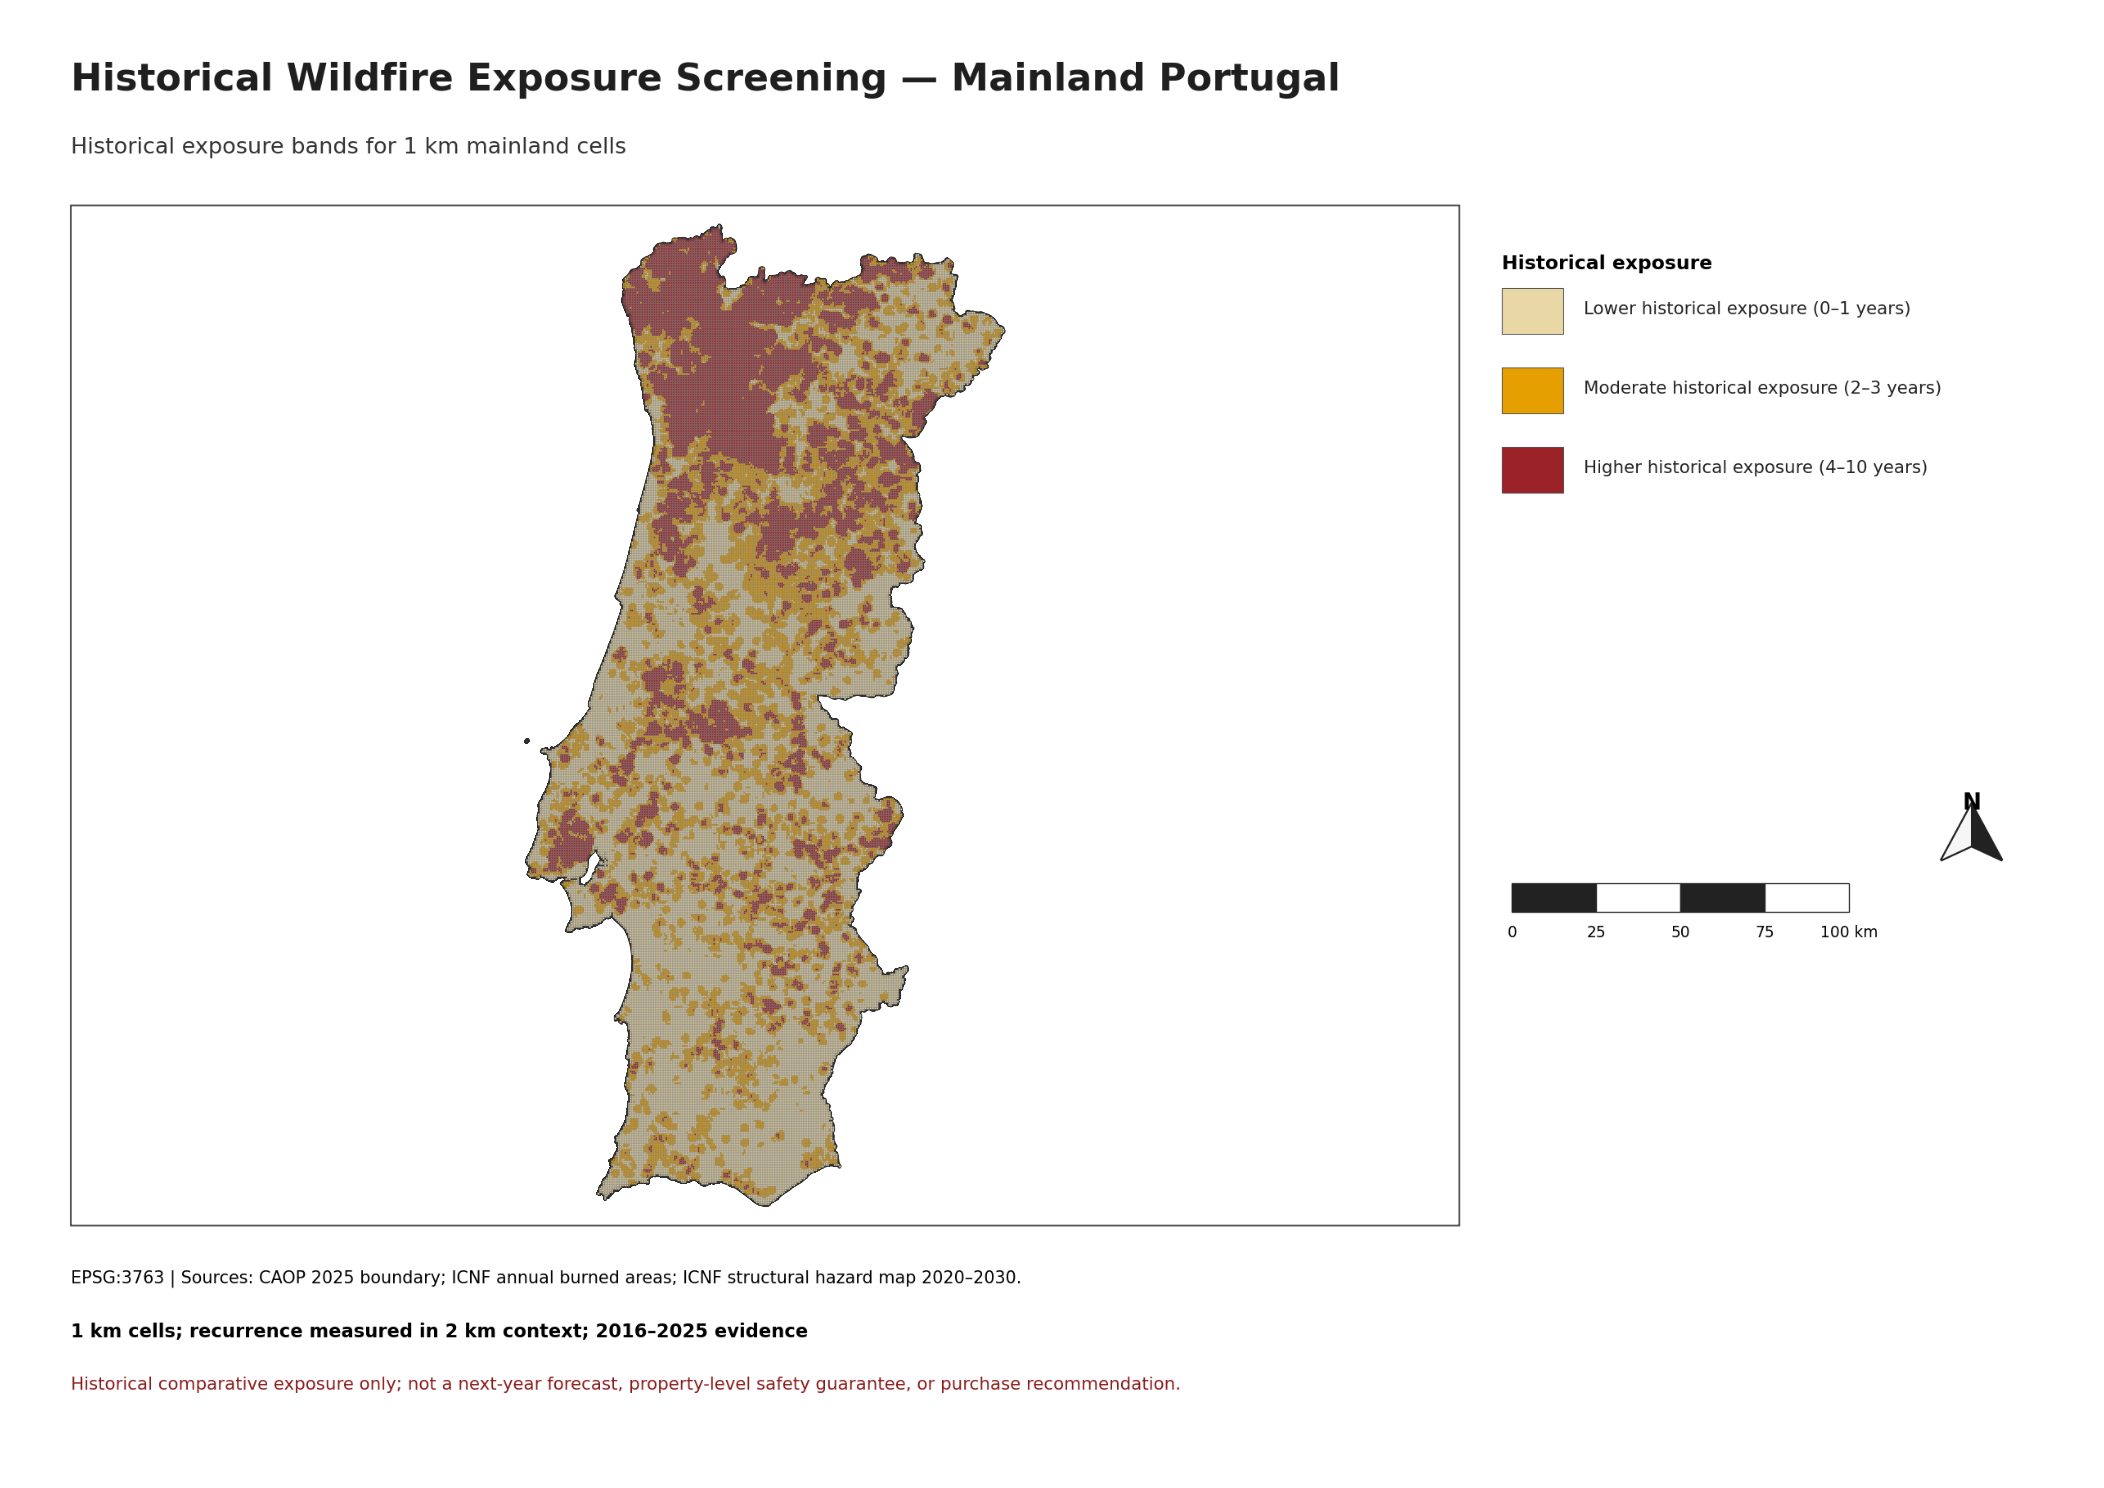

reports/figures/historical_exposure_and_official_icnf_structural_hazard_comparison.png


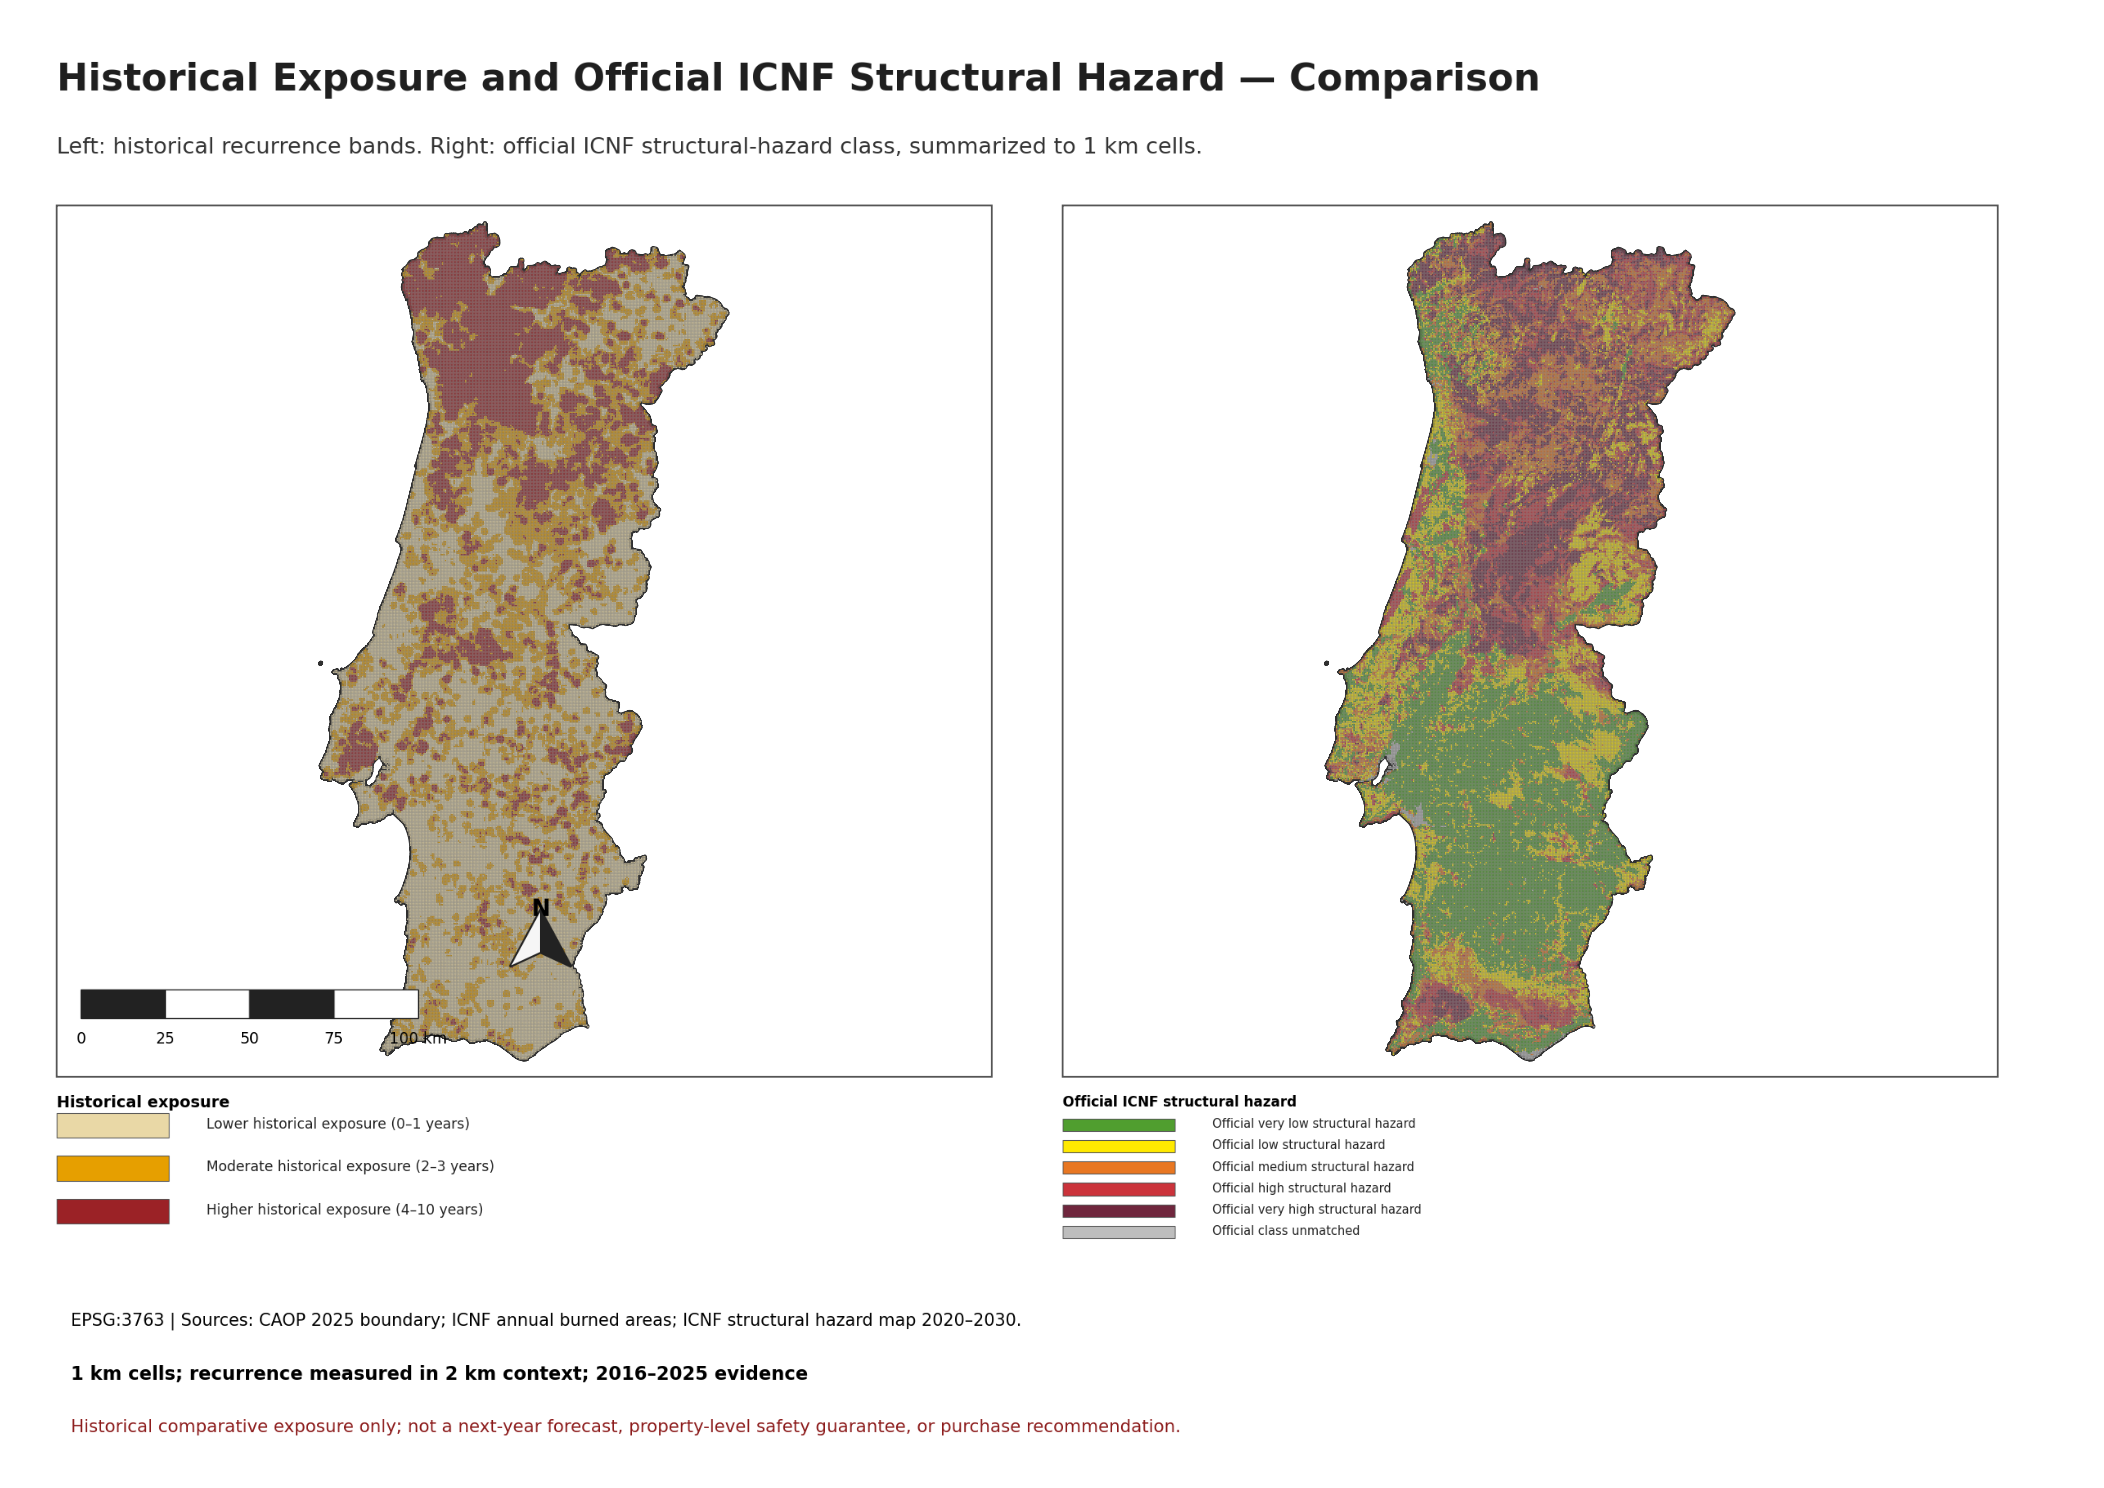

In [5]:
from IPython.display import Image, display

for relative_path in (
    'reports/figures/historical_wildfire_exposure_screening_mainland_portugal.png',
    'reports/figures/historical_exposure_and_official_icnf_structural_hazard_comparison.png',
):
    path = PROJECT_ROOT / relative_path
    assert path.exists(), f'Missing validated presentation figure: {relative_path}'
    print(relative_path)
    display(Image(filename=str(path)))

## Interactive and exported presentation outputs

The QGIS project is an interactive presentation of the same validated `historical_exposure_screening` layer inspected above—not a separate analytical workflow.

- [Open the QGIS project](../qgis/wildfire_exposure_screening_portugal.qgz)
- [Read the QGIS instructions and layer meanings](../qgis/README.md)
- [Read the screening and ICNF comparison report](../reports/validation/historical_exposure_screening_and_icnf_comparison.md)
- [Historical exposure map](../reports/figures/historical_wildfire_exposure_screening_mainland_portugal.png)
- [Historical exposure and official ICNF comparison map](../reports/figures/historical_exposure_and_official_icnf_structural_hazard_comparison.png)

Lower historical exposure does not mean zero wildfire risk. The output supports broad location comparison and shortlisting only; it is not a next-year forecast, property-level safety guarantee, or purchase recommendation.